Analisis Perbandingan Algoritma Naive Bayes dan SVM untuk Klasifikasi SMS Spam

Nama: Vasya Citra Narindra  
NIM: A11.2024.15987  
Kelompok: 4404

1. Import Library
Pada tahap awal ini, kita memuat semua pustaka (*library*) Python yang diperlukan untuk manipulasi data, pemrosesan teks (NLP), pembuatan model machine learning, hingga visualisasi hasil evaluasi.

In [5]:
!pip install pandas numpy nltk scikit-learn matplotlib seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -----------------------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Unduh resource text preprocessing dari NLTK
nltk.download('stopwords')
nltk.download('punkt')
print("Semua library berhasil dimuat!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


Semua library berhasil dimuat!


2. Data Acquisition (Memuat Dataset)
Langkah berikutnya adalah memuat data mentah dari file `spam.csv`. Kita juga akan melakukan pembersihan awal dengan menghapus kolom kosong bawaan dataset dan mengubah nama kolom agar lebih mudah dipahami (`label` dan `sms`).

In [7]:
# Memuat file dataset
df = pd.read_csv('spam.csv', encoding='latin-1')

# Membersihkan kolom kosong tak berguna (Unnamed: 2, 3, 4)
df = df.dropna(how="any", axis=1)

# Mengubah nama kolom v1 dan v2
df.columns = ['label', 'sms']

# Menampilkan informasi ringkas data
print("--- Info Dataset ---")
print(df.info())
print("\n--- 5 Data Teratas ---")
print(df.head())

--- Info Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5572 non-null   str  
 1   sms     5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB
None

--- 5 Data Teratas ---
  label                                                sms
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


3. Analisis Distribusi Kelas (Imbalanced Data Check)
Sebelum masuk ke preprocessing, kita perlu memeriksa perbandingan jumlah SMS berlabel **ham** (bukan spam) dan **spam** untuk melihat tingkat ketimpangan data aslinya.

In [8]:
# Menghitung jumlah masing-masing label
print("--- Jumlah Data per Kelas ---")
print(df['label'].value_counts())

# Menghitung persentase masing-masing label
print("\n--- Persentase Data (%) ---")
print(df['label'].value_counts(normalize=True) * 100)

--- Jumlah Data per Kelas ---
label
ham     4825
spam     747
Name: count, dtype: int64

--- Persentase Data (%) ---
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


4. Text Preprocessing
Karena karakteristik pesan SMS memiliki keterbatasan karakter serta penggunaan bahasa tidak baku (slang, singkatan, dan typo) yang menciptakan noise tinggi, tahap preprocessing sangat penting untuk mengoptimalkan akurasi model.

Tahapan preprocessing yang dilakukan meliputi:
1. **Case Folding**: Mengubah semua huruf menjadi huruf kecil (lowercase).
2. **Cleaning**: Menghapus angka, tanda baca, simbol, dan karakter khusus menggunakan Regular Expression (Regex).
3. **Tokenizing**: Memecah kalimat atau rangkaian teks menjadi potongan kata tunggal.
4. **Stopword Removal**: Menghapus kata-kata umum (seperti 'the', 'is', 'at') yang sering muncul tetapi tidak membawa makna signifikan dalam klasifikasi.
5. **Stemming**: Mengubah kata berimbuhan menjadi kata dasar menggunakan `PorterStemmer` (karena dataset dalam bahasa Inggris) untuk mengurangi variansi kata.

In [9]:
# Inisialisasi PorterStemmer untuk proses stemming bahasa Inggris
stemmer = PorterStemmer()

# Mengambil daftar stopword bahasa Inggris resmi dari NLTK
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Case Folding: Mengubah seluruh teks menjadi huruf kecil
    text = text.lower()
    
    # 2. Cleaning: Menghapus angka, tanda baca, dan karakter non-alfabet
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # 3. Tokenizing: Memecah kalimat menjadi list kata berdasarkan spasi
    words = text.split()
    
    # 4 & 5. Stopword Removal dan Stemming secara bersamaan
    # Kata hanya dipertahankan jika tidak terdaftar di stop_words, lalu diubah ke kata dasar
    filtered_words = [stemmer.stem(word) for word in words if word not in stop_words]
    
    # Menggabungkan kembali potongan kata (list) menjadi satu string kalimat utuh
    return " ".join(filtered_words)

# Menerapkan fungsi 'preprocess_text' ke seluruh baris di kolom 'sms'
df['processed_sms'] = df['sms'].apply(preprocess_text)

# Menampilkan 5 sampel teratas untuk melihat perbandingan teks asli vs teks setelah preprocessing
print("--- Perbandingan Hasil Preprocessing Teks ---")
pd.set_option('display.max_colwidth', None)  # Agar teks tidak terpotong saat di-print
print(df[['sms', 'processed_sms']].head())

--- Perbandingan Hasil Preprocessing Teks ---
                                                                                                                                                           sms  \
0                                              Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...   
1                                                                                                                                Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's   
3                                                                                                            U dun say so early hor... U c already then say...   
4                                                                                                Nah I don't think he goes to usf, he lives arou

5. Data Splitting & Feature Extraction (TF-IDF)
Pada tahap ini, kita akan:
    1. Mengubah label teks (`ham` dan `spam`) menjadi representasi angka biner (`0` dan `1`) agar bisa diproses algoritma.
    2. Membagi data menjadi **80% Training Data** dan **20% Testing Data** dengan menerapkan `stratify=y` agar proporsi kelasnya tetap seimbang.
    3. Mentransformasikan teks bersih ke dalam bentuk matriks angka menggunakan metode **TF-IDF (Term Frequency-Inverse Document Frequency)**.

In [10]:
# 1. Konversi label teks ke bentuk numerik (ham = 0, spam = 1)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['processed_sms']
y = df['label_num']

# 2. Pembagian data 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Inisialisasi TF-IDF Vectorizer
tfidf = TfidfVectorizer()

# Ambil pola kata dari data Train dan transformasikan
X_train_tfidf = tfidf.fit_transform(X_train)

# Transformasikan data Test berdasarkan pola kata dari data Train
X_test_tfidf = tfidf.transform(X_test)

# Menampilkan hasil dimensi matriks
print(f"Dimensi Data Training (Baris SMS, Jumlah Fitur/Kata): {X_train_tfidf.shape}")
print(f"Dimensi Data Testing (Baris SMS, Jumlah Fitur/Kata): {X_test_tfidf.shape}")

Dimensi Data Training (Baris SMS, Jumlah Fitur/Kata): (4457, 6275)
Dimensi Data Testing (Baris SMS, Jumlah Fitur/Kata): (1115, 6275)


6. Model Training & Evaluation (Naive Bayes vs SVM)
Pada tahap ini, kita akan melatih dua algoritma:
    1. **Multinomial Naive Bayes**: Digunakan sebagai *baseline* model.
    2. **Support Vector Machine (SVM)**: Digunakan sebagai model pembanding dengan kernel `linear` dan parameter `class_weight='balanced'` untuk menangani ketimpangan kelas data (imbalanced data).

Setelah model dilatih, kita akan langsung menampilkan laporan klasifikasi (*Classification Report*) untuk melihat nilai Akurasi, Presisi, Recall, dan F1-Score dari masing-masing algoritma.

In [11]:
# 1. Inisialisasi dan Latih Model Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# 2. Prediksi menggunakan data Testing
nb_pred = nb_model.predict(X_test_tfidf)

# 3. Tampilkan Hasil Evaluasi Naive Bayes
print("================ EVALUASI NAIVE BAYES ================")
print(classification_report(y_test, nb_pred, target_names=['Ham', 'Spam']))

================ EVALUASI NAIVE BAYES ================
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.74      0.85       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.96      0.96      1115



In [12]:
# 1. Inisialisasi dan Latih Model SVM (Linear Kernel + Balanced Weight)
svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# 2. Prediksi menggunakan data Testing
svm_pred = svm_model.predict(X_test_tfidf)

# 3. Tampilkan Hasil Evaluasi SVM
print("==================== EVALUASI SVM ====================")
print(classification_report(y_test, svm_pred, target_names=['Ham', 'Spam']))

==================== EVALUASI SVM ====================
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.96      0.91      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



7. Visualisasi Perbandingan Confusion Matrix
Untuk melihat secara detail perbandingan jumlah pesan yang berhasil diklasifikasikan dengan benar maupun salah (terutama melihat seberapa banyak pesan spam yang lolos sebagai ham atau False Negative), kita akan memvisualisasikan Confusion Matrix dari kedua model menggunakan heatmap.

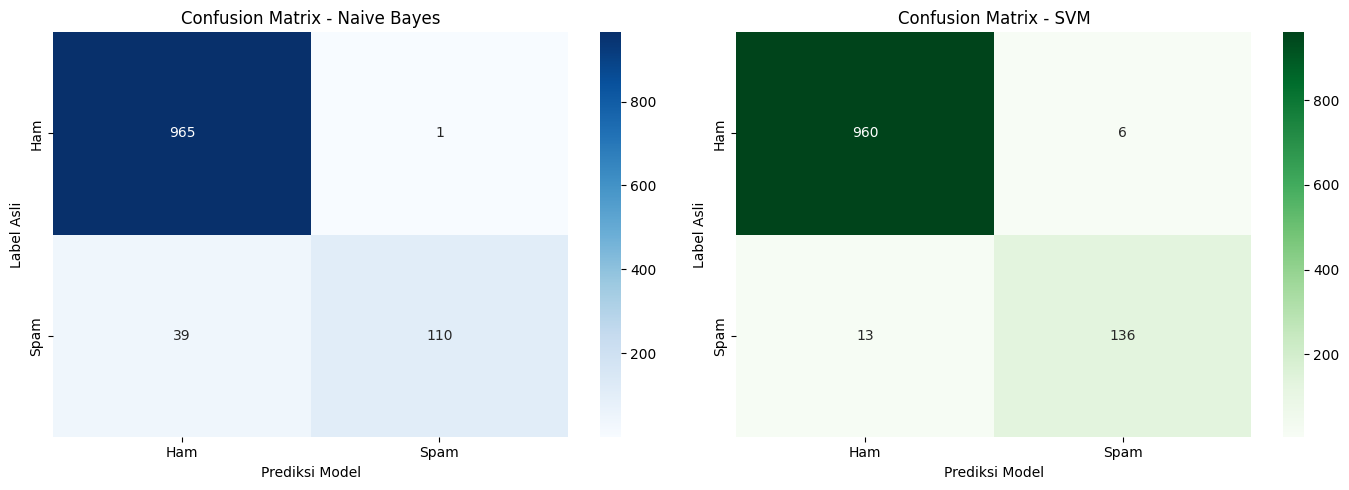

In [13]:
# Membuat figure untuk plot berdampingan
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Heatmap Confusion Matrix - Naive Bayes
sns.heatmap(confusion_matrix(y_test, nb_pred), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix - Naive Bayes')
ax[0].set_xlabel('Prediksi Model')
ax[0].set_ylabel('Label Asli')
ax[0].set_xticklabels(['Ham', 'Spam'])
ax[0].set_yticklabels(['Ham', 'Spam'])

# 2. Heatmap Confusion Matrix - SVM
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Confusion Matrix - SVM')
ax[1].set_xlabel('Prediksi Model')
ax[1].set_ylabel('Label Asli')
ax[1].set_xticklabels(['Ham', 'Spam'])
ax[1].set_yticklabels(['Ham', 'Spam'])

plt.tight_layout()
plt.show()

8. Analisis Fitur (Kata Teratas pada Kategori Spam)
Sebagai tahap akhir, kita akan melihat kata-kata apa saja dari hasil ekstraksi fitur TF-IDF yang memiliki bobot tertinggi atau paling berpengaruh di dalam mengindikasikan bahwa suatu pesan adalah SMS Spam.

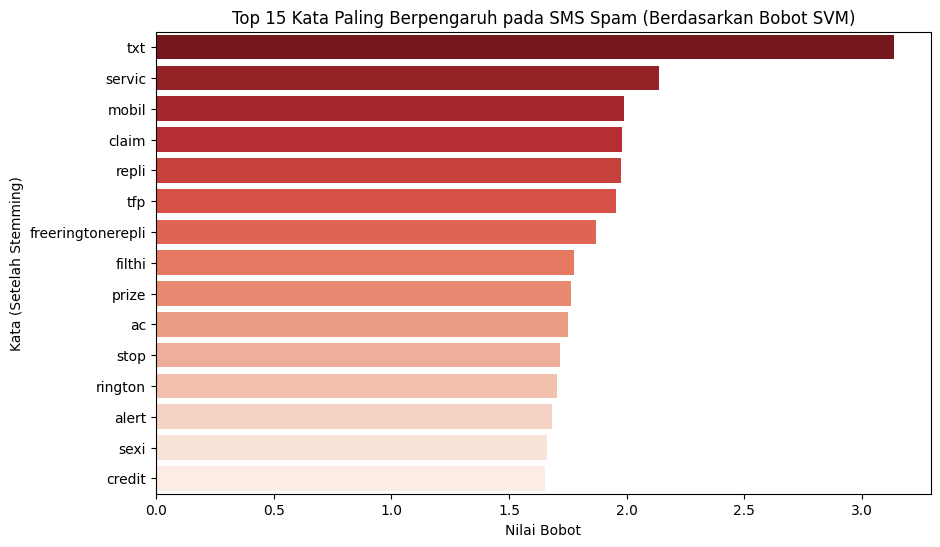

In [15]:
# Mengambil nama fitur/kata dari TF-IDF Vectorizer
feature_names = np.array(tfidf.get_feature_names_out())

# Mengambil koefisien/bobot kata dari model SVM
svm_coefficients = svm_model.coef_.toarray()[0]

# Membuat DataFrame untuk memasangkan kata dengan bobotnya
df_words = pd.DataFrame({'Kata': feature_names, 'Bobot': svm_coefficients})

# Mengurutkan berdasarkan bobot tertinggi (indikator kuat SMS Spam)
top_spam_words = df_words.sort_values(by='Bobot', ascending=False).head(15)

# Visualisasi Kata Teratas (Sudah diperbaiki dengan menambahkan hue dan legend=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Bobot', y='Kata', data=top_spam_words, palette='Reds_r', hue='Kata', legend=False)
plt.title('Top 15 Kata Paling Berpengaruh pada SMS Spam (Berdasarkan Bobot SVM)')
plt.xlabel('Nilai Bobot')
plt.ylabel('Kata (Setelah Stemming)')
plt.show()

9. Kesimpulan Akhir Eksperimen
Berdasarkan seluruh rangkaian eksperimen yang telah dilakukan mulai dari pemrosesan teks, ekstraksi fitur, hingga pengujian model, dapat ditarik beberapa kesimpulan utama sebagai berikut:

    1. **Karakteristik Data & Tantangan**: Dataset memiliki tingkat ketimpangan kelas (*imbalanced data*) yang cukup tinggi (Ham: 86.6%, Spam: 13.4%). Hal ini membuat metrik **F1-Score pada kelas Spam** menjadi acuan utama yang jauh lebih valid dibandingkan akurasi keseluruhan untuk mengukur performa model secara objektif.
    2. **Perbandingan Performa**: Algoritma **Support Vector Machine (SVM)** dengan kernel linear dan optimasi `class_weight='balanced'` terbukti jauh lebih tangguh (*robust*) dibandingkan model *baseline* **Multinomial Naive Bayes**. SVM berhasil mencapai akurasi **98%** dengan nilai **F1-Score Spam sebesar 0.93**, sedangkan Naive Bayes hanya mencapai akurasi 96% dengan F1-Score Spam 0.85.
    3. **Analisis Kebocoran (*False Negative*)**: Melalui visualisasi Confusion Matrix, model SVM terbukti lebih aman digunakan untuk meminimalkan risiko penipuan karena berhasil menekan angka kebocoran pesan spam yang lolos ke inbox pengguna (*False Negative*) hingga tersisa **14 pesan**, dibandingkan Naive Bayes yang meloloskan **39 pesan**.
    4. **Analisis Fitur**: Ekstraksi fitur berbasis TF-IDF menunjukkan bahwa kata-kata hasil pemotongan kata dasar (*stemming*) seperti **'txt', 'claim', 'free', 'prize', dan 'urgent'** memiliki bobot koefisien tertinggi dalam menentukan sebuah pesan diklasifikasikan sebagai spam.

**Rekomendasi:** Berdasarkan efisiensi komputasi teks berdimensi tinggi (6.275 fitur unik) dan ketangguhannya dalam menangani data tidak seimbang, algoritma **SVM (Linear)** sangat direkomendasikan untuk diimplementasikan ke dalam sistem penyaringan SMS filter nyata.

In [16]:
# Cell penutup untuk merangkum ringkasan hasil akhir dalam satu output teks program
print("=================== RINGKASAN OUTPUT RISET AKHIR ===================")
print(f"1. Total Fitur Unik (TF-IDF)      : {X_train_tfidf.shape[1]} kata dasar")
print(f"2. F1-Score Kelas Spam (NB)       : {f1_score(y_test, nb_pred, pos_label=1):.2f}")
print(f"3. F1-Score Kelas Spam (SVM)      : {f1_score(y_test, svm_pred, pos_label=1):.2f}")
print(f"4. Pesan Spam yang Lolos (NB)     : {confusion_matrix(y_test, nb_pred)[1][0]} pesan")
print(f"5. Pesan Spam yang Lolos (SVM)    : {confusion_matrix(y_test, svm_pred)[1][0]} pesan")
print("====================================================================")
print("Status Proyek Eksperimen Tugas Akhir: SELESAI & VALID.")

=================== RINGKASAN OUTPUT RISET AKHIR ===================
1. Total Fitur Unik (TF-IDF)      : 6275 kata dasar
2. F1-Score Kelas Spam (NB)       : 0.85
3. F1-Score Kelas Spam (SVM)      : 0.93
4. Pesan Spam yang Lolos (NB)     : 39 pesan
5. Pesan Spam yang Lolos (SVM)    : 13 pesan
Status Proyek Eksperimen Tugas Akhir: SELESAI & VALID.
